# LSTM time step regression framing

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pandas import read_csv
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import LSTM
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [2]:
# convert an array of values into a dataset matrix
def create_dataset(dataset, look_back=1):
	dataX, dataY = [], []
	for i in range(len(dataset)-look_back-1):
		a = dataset[i:(i+look_back), 0]
		dataX.append(a)
		dataY.append(dataset[i + look_back, 0])
	return np.array(dataX), np.array(dataY)

# fix random seed for reproducibility
tf.random.set_seed(42)

# load the dataset
dataframe = read_csv('airline-passengers.csv', usecols=[1], engine='python')
dataset = dataframe.values
dataset = dataset.astype('float32')

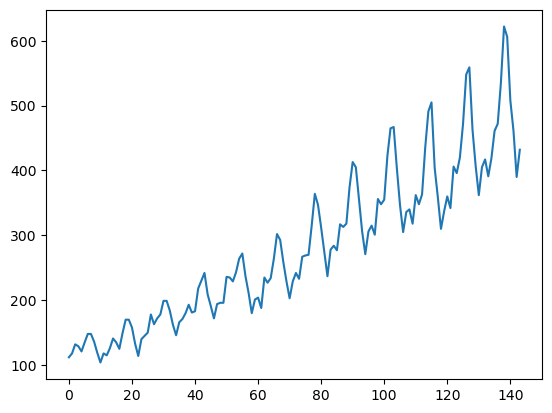

In [3]:
plt.plot(dataset)
plt.show()

In [4]:
# normalize the dataset
scaler = MinMaxScaler(feature_range=(0, 1))
dataset = scaler.fit_transform(dataset)

In [5]:
# split into train and test sets
train_size = int(len(dataset) * 0.7)
test_size = len(dataset) - train_size
train, test = dataset[0:train_size,:], dataset[train_size:len(dataset),:]

# reshape into X=t and Y=t+1
look_back = 12
trainX, trainY = create_dataset(train, look_back)
testX, testY = create_dataset(test, look_back)

# reshape input to be [samples, time steps, features] - LSTM expects 3D input
trainX = np.reshape(trainX, (trainX.shape[0], trainX.shape[1], 1))
testX = np.reshape(testX, (testX.shape[0], testX.shape[1], 1))

In [6]:
# create and fit the LSTM network
model = Sequential()
model.add(LSTM(32, 
               input_shape=(look_back, 1)))
model.add(Dense(1))
model.compile(loss='mean_squared_error', 
              optimizer='adam')
model.fit(trainX, 
          trainY, 
          epochs=100, 
          batch_size=16, 
          verbose=2)

c:\Users\isse_\miniconda3\envs\lab3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/100
6/6 - 2s - 374ms/step - loss: 0.0915
Epoch 2/100
6/6 - 0s - 13ms/step - loss: 0.0516
Epoch 3/100
6/6 - 0s - 13ms/step - loss: 0.0235
Epoch 4/100
6/6 - 0s - 13ms/step - loss: 0.0088
Epoch 5/100
6/6 - 0s - 14ms/step - loss: 0.0097
Epoch 6/100
6/6 - 0s - 25ms/step - loss: 0.0105
Epoch 7/100
6/6 - 0s - 22ms/step - loss: 0.0077
Epoch 8/100
6/6 - 0s - 13ms/step - loss: 0.0070
Epoch 9/100
6/6 - 0s - 13ms/step - loss: 0.0066
Epoch 10/100
6/6 - 0s - 14ms/step - loss: 0.0061
Epoch 11/100
6/6 - 0s - 13ms/step - loss: 0.0059
Epoch 12/100
6/6 - 0s - 13ms/step - loss: 0.0058
Epoch 13/100
6/6 - 0s - 16ms/step - loss: 0.0055
Epoch 14/100
6/6 - 0s - 18ms/step - loss: 0.0052
Epoch 15/100
6/6 - 0s - 18ms/step - loss: 0.0051
Epoch 16/100
6/6 - 0s - 18ms/step - loss: 0.0049
Epoch 17/100
6/6 - 0s - 16ms/step - loss: 0.0049
Epoch 18/100
6/6 - 0s - 15ms/step - loss: 0.0048
Epoch 19/100
6/6 - 0s - 17ms/step - loss: 0.0047
Epoch 20/100
6/6 - 0s - 27ms/step - loss: 0.0047
Epoch 21/100
6/6 - 0s - 18ms

In [ ]:
# You can add another layer

# model = Sequential()
# model.add(LSTM(32, return_sequences=True, input_shape=(1, look_back)))
# model.add(LSTM(16))
# model.add(Dense(1))

In [7]:
# make predictions
trainPredict = model.predict(trainX)
testPredict = model.predict(testX)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step


In [8]:
# invert predictions
trainPredict = scaler.inverse_transform(trainPredict)
trainY = scaler.inverse_transform([trainY])
testPredict = scaler.inverse_transform(testPredict)
testY = scaler.inverse_transform([testY])

In [9]:
# calculate root mean squared error
trainScore = np.sqrt(mean_squared_error(trainY[0], trainPredict[:,0]))
print('Train Score: %.2f RMSE' % (trainScore))
testScore = np.sqrt(mean_squared_error(testY[0], testPredict[:,0]))
print('Test Score: %.2f RMSE' % (testScore))

Train Score: 25.63 RMSE
Test Score: 65.75 RMSE


In [10]:
# shift train predictions for plotting
trainPredictPlot = np.empty_like(dataset)
trainPredictPlot[:, :] = np.nan
trainPredictPlot[look_back:len(trainPredict)+look_back, :] = trainPredict

In [11]:
# shift test predictions for plotting
testPredictPlot = np.empty_like(dataset)
testPredictPlot[:, :] = np.nan
testPredictPlot[len(trainPredict)+(look_back*2)+1:len(dataset)-1, :] = testPredict

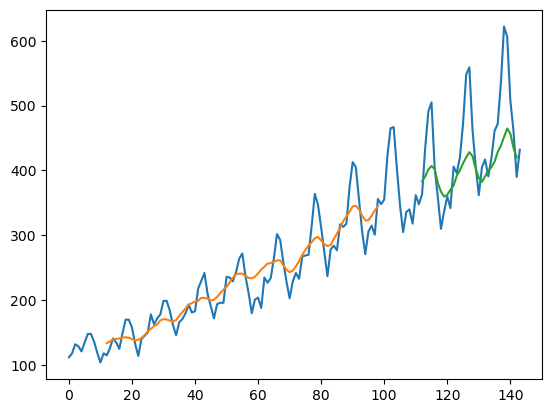

In [12]:
# plot baseline and predictions
plt.plot(scaler.inverse_transform(dataset))
plt.plot(trainPredictPlot)
plt.plot(testPredictPlot)
plt.show()

## USING NEURAL NETWORK

In [13]:
# Split
train_size = int(len(dataset) * 0.7)
train, test = dataset[:train_size, :], dataset[train_size:, :]

# Supervised framing
look_back = 12   # use 1 year of history
train_X, train_Y = create_dataset(train, look_back)
test_X, test_Y = create_dataset(test, look_back)

Define the NN model

In [14]:
model = Sequential()
model.add(Dense(64, activation="relu", input_shape=(look_back,)))
model.add(Dense(32, activation="relu"))
model.add(Dense(1))

model.compile(loss="mse", optimizer="adam")

c:\Users\isse_\miniconda3\envs\lab3\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [15]:
# Train
model.fit(train_X, train_Y, epochs=200, batch_size=16, verbose=2)

Epoch 1/200
6/6 - 1s - 205ms/step - loss: 0.0472
Epoch 2/200
6/6 - 0s - 17ms/step - loss: 0.0089
Epoch 3/200
6/6 - 0s - 12ms/step - loss: 0.0088
Epoch 4/200
6/6 - 0s - 12ms/step - loss: 0.0092
Epoch 5/200
6/6 - 0s - 11ms/step - loss: 0.0052
Epoch 6/200
6/6 - 0s - 11ms/step - loss: 0.0043
Epoch 7/200
6/6 - 0s - 11ms/step - loss: 0.0037
Epoch 8/200
6/6 - 0s - 12ms/step - loss: 0.0029
Epoch 9/200
6/6 - 0s - 11ms/step - loss: 0.0026
Epoch 10/200
6/6 - 0s - 11ms/step - loss: 0.0023
Epoch 11/200
6/6 - 0s - 11ms/step - loss: 0.0019
Epoch 12/200
6/6 - 0s - 11ms/step - loss: 0.0017
Epoch 13/200
6/6 - 0s - 12ms/step - loss: 0.0015
Epoch 14/200
6/6 - 0s - 11ms/step - loss: 0.0014
Epoch 15/200
6/6 - 0s - 12ms/step - loss: 0.0012
Epoch 16/200
6/6 - 0s - 11ms/step - loss: 0.0011
Epoch 17/200
6/6 - 0s - 11ms/step - loss: 0.0010
Epoch 18/200
6/6 - 0s - 11ms/step - loss: 9.6315e-04
Epoch 19/200
6/6 - 0s - 11ms/step - loss: 9.0834e-04
Epoch 20/200
6/6 - 0s - 11ms/step - loss: 8.6790e-04
Epoch 21/200
6/6

In [16]:
# Predict
train_Predict = model.predict(train_X)
test_Predict = model.predict(test_X)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


In [17]:
# Invert scaling

train_Predict = scaler.inverse_transform(train_Predict)
train_Y_inv = scaler.inverse_transform(train_Y.reshape(-1, 1))

test_Predict = scaler.inverse_transform(test_Predict)
test_Y_inv = scaler.inverse_transform(test_Y.reshape(-1, 1))

In [18]:
# Metrics

trainRMSE = np.sqrt(mean_squared_error(train_Y_inv[:, 0], train_Predict[:, 0]))
testRMSE = np.sqrt(mean_squared_error(test_Y_inv[:, 0], test_Predict[:, 0]))

trainMAE = mean_absolute_error(train_Y_inv[:, 0], train_Predict[:, 0])
testMAE = mean_absolute_error(test_Y_inv[:, 0], test_Predict[:, 0])

r2 = r2_score(test_Y_inv[:, 0], test_Predict[:, 0])

print(f"Train RMSE: {trainRMSE:.2f}")
print(f"Test RMSE : {testRMSE:.2f}")
print(f"Test MAE  : {testMAE:.2f}")
print(f"Test R2   : {r2:.3f}")

Train RMSE: 7.34
Test RMSE : 20.89
Test MAE  : 15.22
Test R2   : 0.927


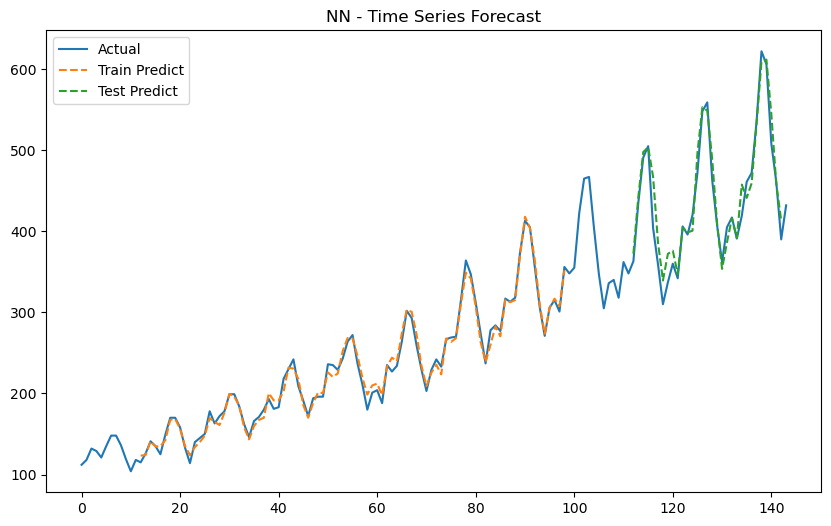

In [19]:
# Plotting
trainPredictPlot = np.empty_like(dataset)
trainPredictPlot[:, :] = np.nan
trainPredictPlot[look_back:len(train_Predict) + look_back, :] = train_Predict

testPredictPlot = np.empty_like(dataset)
testPredictPlot[:, :] = np.nan
testPredictPlot[len(train_Predict) + (look_back * 2) + 1:len(dataset) - 1, :] = test_Predict

plt.figure(figsize=(10,6))
plt.plot(scaler.inverse_transform(dataset), label="Actual")
plt.plot(trainPredictPlot, linestyle="--", label="Train Predict")
plt.plot(testPredictPlot, linestyle="--", label="Test Predict")
plt.legend()
plt.title("NN - Time Series Forecast")
plt.show()